In [3]:
#Getting the cities data from a csv file

import pandas as pd

In [4]:
cities_data = pd.read_csv(r'C:\Users\Username\Downloads\Indian_cities.csv')

In [5]:
cities_data #dataframe created using the csv file

,name_of_city,state_code,state_name,dist_code,population_total,population_male,population_female,0-6_population_total,0-6_population_male,0-6_population_female,...,literates_female,sex_ratio,child_sex_ratio,effective_literacy_rate_total,effective_literacy_rate_male,effective_literacy_rate_female,location,total_graduates,male_graduates,female_graduates
0,Abohar,3,PUNJAB,9,145238,76840,68398,15870,8587,7283,...,44972,890,848,79.86,85.49,73.59,"30.1452928,74.1993043",16287,8612,7675
1,Achalpur,27,MAHARASHTRA,7,112293,58256,54037,11810,6186,5624,...,43086,928,909,91.99,94.77,89.00,"21.257584,77.5086754",8863,5269,3594
2,Adilabad,28,ANDHRA PRADESH,1,117388,59232,58156,13103,6731,6372,...,37660,982,947,80.51,88.18,72.73,"19.0809075,79.560344",10565,6797,3768
3,Adityapur,20,JHARKHAND,24,173988,91495,82493,23042,12063,10979,...,54515,902,910,83.46,89.98,76.23,"22.7834741,86.1576889",19225,12189,7036
4,Adoni,28,ANDHRA PRADESH,21,166537,82743,83794,18406,9355,9051,...,45089,1013,968,68.38,76.58,60.33,"15.6322227,77.2728368",11902,7871,4031
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488,Vizianagaram,28,ANDHRA PRADESH,12,227533,111596,115937,20487,10495,9992,...,80306,1039,952,81.85,88.18,75.80,"18.1066576,83.3955506",30656,19173,11483
489,Warangal,28,ANDHRA PRADESH,9,620116,310400,309716,55392,28434,26958,...,217136,998,948,84.16,91.54,76.79,"17.9689008,79.5940544",109613,69507,40106
490,Wardha,27,MAHARASHTRA,8,105543,53241,52302,9754,5139,4615,...,43339,982,898,94.05,97.19,90.88,"20.745319,78.6021946",19363,10645,8718
491,Yamunanagar,6,HARYANA,3,216628,115404,101224,22905,12556,10349,...,74255,877,824,85.91,89.61,81.71,"30.1290485,77.2673901",29803,14349,15454


In [8]:
cities = list(cities_data["name_of_city"]) # type cast pandas.series to list

In [9]:
type(cities)

list

In [18]:
print(len(cities))

493


In [11]:
import requests

In [19]:
weather_data = []

In [24]:
from tqdm import tqdm #importing tqdm library to check the progress of the data ingestion into the weather_data container

for city in tqdm(cities):
    base_url = "https://api.openweathermap.org/data/2.5/weather"
    params = {
        "q" : city,
        "appid" : "xxx"
    }

    response = requests.get(base_url, params = params)

    data = response.json()

    weather_data.append(data)


100%|██████████| 493/493 [01:51<00:00,  4.44it/s]


In [16]:
print(len(weather_data)) 

493


In [25]:
# weather data - raw is ready and is in json format. Now have to do transformations using dataframe

df = pd.json_normalize(weather_data)

df.columns

Index(['weather', 'base', 'visibility', 'dt', 'timezone', 'id', 'name', 'cod',
       'coord.lon', 'coord.lat', 'main.temp', 'main.feels_like',
       'main.temp_min', 'main.temp_max', 'main.pressure', 'main.humidity',
       'main.sea_level', 'main.grnd_level', 'wind.speed', 'wind.deg',
       'wind.gust', 'clouds.all', 'sys.country', 'sys.sunrise', 'sys.sunset',
       'message', 'rain.1h'],
      dtype='str')

In [27]:
df.T

,0,1,2,3,4,5,6,7,8,9,...,483,484,485,486,487,488,489,490,491,492
weather,"[{'id': 800, 'main': 'Clear', 'description': '...","[{'id': 800, 'main': 'Clear', 'description': '...","[{'id': 800, 'main': 'Clear', 'description': '...",NaN,"[{'id': 804, 'main': 'Clouds', 'description': ...","[{'id': 500, 'main': 'Rain', 'description': 'l...","[{'id': 800, 'main': 'Clear', 'description': '...","[{'id': 800, 'main': 'Clear', 'description': '...","[{'id': 804, 'main': 'Clouds', 'description': ...","[{'id': 500, 'main': 'Rain', 'description': 'l...",...,"[{'id': 804, 'main': 'Clouds', 'description': ...","[{'id': 800, 'main': 'Clear', 'description': '...","[{'id': 800, 'main': 'Clear', 'description': '...","[{'id': 803, 'main': 'Clouds', 'description': ...","[{'id': 500, 'main': 'Rain', 'description': 'l...","[{'id': 500, 'main': 'Rain', 'description': 'l...","[{'id': 803, 'main': 'Clouds', 'description': ...","[{'id': 800, 'main': 'Clear', 'description': '...","[{'id': 800, 'main': 'Clear', 'description': '...","[{'id': 800, 'main': 'Clear', 'description': '..."
base,stations,stations,stations,NaN,stations,stations,stations,stations,stations,stations,...,stations,stations,stations,stations,stations,stations,stations,stations,stations,stations
visibility,10000.0,10000.0,10000.0,NaN,10000.0,10000.0,10000.0,10000.0,10000.0,8716.0,...,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
dt,1790926621.0,1790926621.0,1790926414.0,NaN,1790926622.0,1790926401.0,1790926605.0,1790926538.0,1790926436.0,1790926623.0,...,1790926526.0,1790926702.0,1790926731.0,1790926731.0,1790926722.0,1790926731.0,1790926731.0,1790926732.0,1790926732.0,1790926732.0
timezone,19800.0,19800.0,19800.0,NaN,19800.0,19800.0,19800.0,19800.0,19800.0,19800.0,...,19800.0,19800.0,19800.0,19800.0,19800.0,19800.0,19800.0,19800.0,19800.0,19800.0
id,1279403.0,1279390.0,1279344.0,NaN,1279335.0,1279290.0,1279259.0,1279233.0,1279228.0,1279186.0,...,1253286.0,1253237.0,1253200.0,1253184.0,1253102.0,1253084.0,1252948.0,1252942.0,1257806.0,1252770.0
name,Abohar,Achalpur,Adilabad,NaN,Adoni,Agartala,Agra,Ahmadabad,Ahmadnagar,Aizawl,...,Vellore,Veraval,Vidisha,Vijayawada,Visakhapatnam,Vizianagaram,Warangal,Wardha,Yamunanagar,Yavatmal
cod,200,200,200,404,200,200,200,200,200,200,...,200,200,200,200,200,200,200,200,200,200
coord.lon,74.1833,77.5086,78.5333,NaN,77.2833,91.275,78.0167,72.6167,74.7333,92.7167,...,79.1333,70.3667,77.8167,80.6167,83.2093,83.4167,79.5833,78.6167,77.2833,78.1333
coord.lat,30.15,21.2572,19.6667,NaN,15.6333,23.8364,27.1833,23.0333,19.0833,23.7333,...,12.9333,20.9,23.5333,16.5167,17.69,18.1167,18.0,20.75,30.1,20.4


In [26]:
df_clean = df[[
    "name",
    "coord.lon",
    "coord.lat",
    "main.temp",
    "main.feels_like",
    "main.pressure",
    "main.humidity",
    "wind.speed",
    "sys.sunrise",
    "sys.sunset"
]]

In [30]:
df["weather"].isna() # this gives me if any city has no weather data

0      False
1      False
2      False
3       True
4      False
       ...  
488    False
489    False
490    False
491    False
492    False
Name: weather, Length: 493, dtype: bool

In [31]:
# finding the no of cities without weather data

df["weather"].isna().sum()

np.int64(117)

In [32]:
df[df["weather"].isna()] # these are the rows with no weather data. 

,weather,base,visibility,dt,timezone,id,name,cod,coord.lon,coord.lat,...,main.grnd_level,wind.speed,wind.deg,wind.gust,clouds.all,sys.country,sys.sunrise,sys.sunset,message,rain.1h
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,404,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,city not found,NaN
14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,404,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,city not found,NaN
19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,404,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,city not found,NaN
20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,404,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,city not found,NaN
45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,404,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,city not found,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,404,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,city not found,NaN
473,NaN,NaN,NaN,NaN,NaN,NaN,NaN,404,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,city not found,NaN
476,NaN,NaN,NaN,NaN,NaN,NaN,NaN,404,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,city not found,NaN
478,NaN,NaN,NaN,NaN,NaN,NaN,NaN,404,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,city not found,NaN


In [35]:
df_clean["weather"] = df["weather"].apply(
    lambda x:x[0]["main"] 
    if isinstance(x,list) 
    and len(x) > 0 
    else None 
)

In [36]:
df_clean["weather_desc"] = df["weather"].apply(
    lambda x:x[0]["description"]
    if isinstance(x,list)
    and len(x) > 0
    else None
)

In [37]:
df_clean

,name,coord.lon,coord.lat,main.temp,main.feels_like,main.pressure,main.humidity,wind.speed,sys.sunrise,sys.sunset,weather,weather_desc
0,Abohar,74.1833,30.1500,311.55,309.15,1012.0,14.0,3.73,1.790903e+09,1.790945e+09,Clear,clear sky
1,Achalpur,77.5086,21.2572,306.20,305.51,1014.0,32.0,4.04,1.790902e+09,1.790945e+09,Clear,clear sky
2,Adilabad,78.5333,19.6667,305.58,307.57,1014.0,47.0,3.11,1.790901e+09,1.790944e+09,Clear,clear sky
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Adoni,77.2833,15.6333,305.74,305.91,1012.0,38.0,4.09,1.790902e+09,1.790945e+09,Clouds,overcast clouds
...,...,...,...,...,...,...,...,...,...,...,...,...
488,Vizianagaram,83.4167,18.1167,305.26,310.79,1012.0,61.0,2.19,1.790900e+09,1.790943e+09,Rain,light rain
489,Warangal,79.5833,18.0000,306.05,309.82,1013.0,52.0,3.34,1.790901e+09,1.790944e+09,Clouds,broken clouds
490,Wardha,78.6167,20.7500,306.53,307.54,1014.0,40.0,1.58,1.790901e+09,1.790944e+09,Clear,clear sky
491,Yamunanagar,77.2833,30.1000,305.95,307.05,1012.0,42.0,3.10,1.790902e+09,1.790945e+09,Clear,clear sky


In [40]:
# creating temperature column
df_clean["temp_c"] = df_clean["main.temp"]-273.15 

In [41]:
#creating dataframe without the NAs

df_filtered = df_clean[df_clean["weather"].notna()] # not na is used here to filter out the rows that are not NA

In [42]:
df_filtered

,name,coord.lon,coord.lat,main.temp,main.feels_like,main.pressure,main.humidity,wind.speed,sys.sunrise,sys.sunset,weather,weather_desc,temp_c
0,Abohar,74.1833,30.1500,311.55,309.15,1012.0,14.0,3.73,1.790903e+09,1.790945e+09,Clear,clear sky,38.40
1,Achalpur,77.5086,21.2572,306.20,305.51,1014.0,32.0,4.04,1.790902e+09,1.790945e+09,Clear,clear sky,33.05
2,Adilabad,78.5333,19.6667,305.58,307.57,1014.0,47.0,3.11,1.790901e+09,1.790944e+09,Clear,clear sky,32.43
4,Adoni,77.2833,15.6333,305.74,305.91,1012.0,38.0,4.09,1.790902e+09,1.790945e+09,Clouds,overcast clouds,32.59
5,Agartala,91.2750,23.8364,304.05,310.48,1012.0,70.0,3.35,1.790898e+09,1.790941e+09,Rain,light rain,30.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...
488,Vizianagaram,83.4167,18.1167,305.26,310.79,1012.0,61.0,2.19,1.790900e+09,1.790943e+09,Rain,light rain,32.11
489,Warangal,79.5833,18.0000,306.05,309.82,1013.0,52.0,3.34,1.790901e+09,1.790944e+09,Clouds,broken clouds,32.90
490,Wardha,78.6167,20.7500,306.53,307.54,1014.0,40.0,1.58,1.790901e+09,1.790944e+09,Clear,clear sky,33.38
491,Yamunanagar,77.2833,30.1000,305.95,307.05,1012.0,42.0,3.10,1.790902e+09,1.790945e+09,Clear,clear sky,32.80


In [43]:
# sorting the dataframe on the basis of temperature

df_sorted = df_filtered.sort_values("temp_c")

In [45]:
# Plotting graph for the weather dataframe

import matplotlib.pyplot as plt

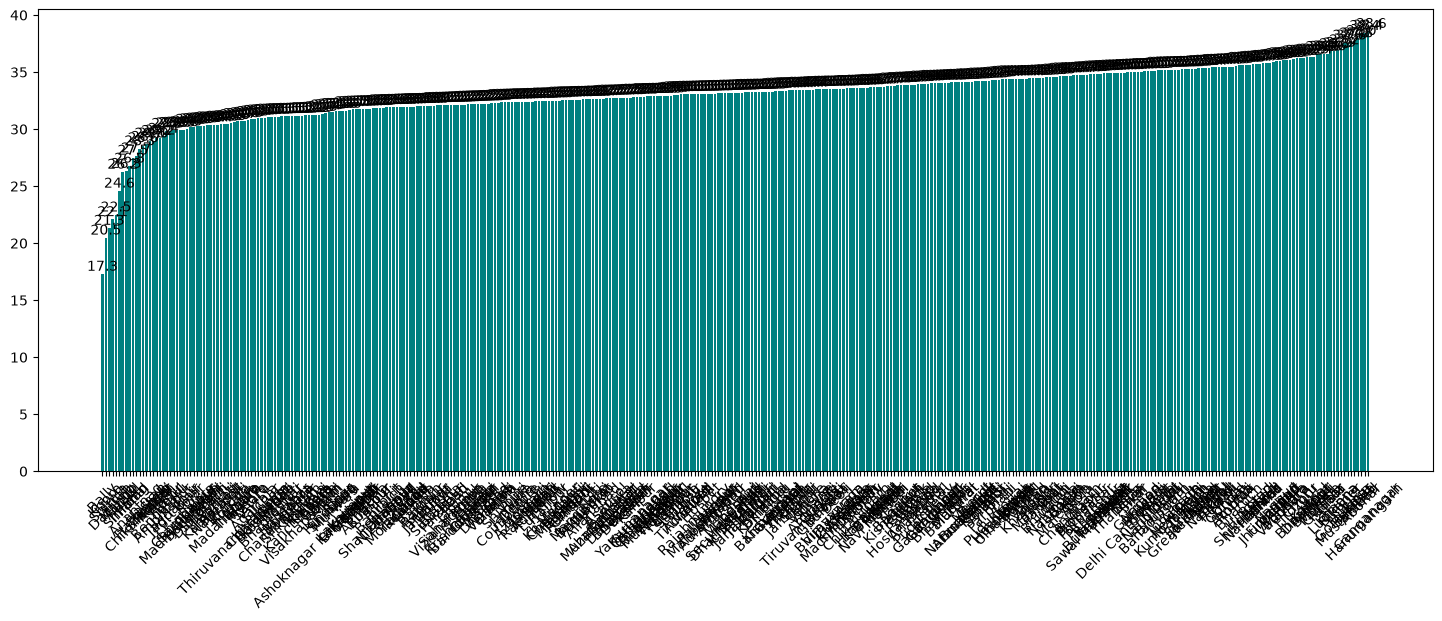

In [48]:
#declaring the size of the chart
plt.figure(figsize=(18,6)) # = symbol or assignment operator is mandatory to decalare the horizontal and vertical size

plt.bar(df_sorted["name"],df_sorted["temp_c"],color = 'teal') #declaring the x axis, y axis and the color of the bars

#bringing in the datalabels

for i, value in enumerate(df_sorted["temp_c"]):
    plt.text(i,value,round(value,1),ha = 'center',va = 'bottom')

plt.xticks(rotation = 45)

plt.show()

In [52]:
#getting only the top 10 cities with lowest temperatures

df_top_low = df_sorted.head(10)

In [53]:
df_top_high = df_sorted.tail(10)

In [54]:
df_top_low

,name,coord.lon,coord.lat,main.temp,main.feels_like,main.pressure,main.humidity,wind.speed,sys.sunrise,sys.sunset,weather,weather_desc,temp_c
47,Bally,-75.5871,40.4023,290.44,290.57,1015.0,90.0,2.77,1.790939e+09,1.790981e+09,Clouds,broken clouds,17.29
266,Khora,21.7167,37.0500,293.61,292.94,1024.0,47.0,3.54,1.790915e+09,1.790958e+09,Clear,clear sky,20.46
431,Shimla,77.1667,31.1000,294.47,293.83,1016.0,45.0,2.63,1.790902e+09,1.790945e+09,Clear,clear sky,21.32
135,Darjiling,88.2667,27.0333,295.23,295.50,1014.0,77.0,1.74,1.790899e+09,1.790942e+09,Rain,light rain,22.08
31,Arrah,-3.9722,6.6653,295.64,296.22,1017.0,87.0,1.76,1.790921e+09,1.790964e+09,Clouds,overcast clouds,22.49
305,Mango,-82.3065,27.9797,297.73,298.62,1016.0,91.0,2.54,1.790940e+09,1.790983e+09,Clouds,overcast clouds,24.58
9,Aizawl,92.7167,23.7333,299.39,299.39,1014.0,79.0,1.03,1.790898e+09,1.790941e+09,Rain,light rain,26.24
430,Shillong,91.8831,25.5689,299.46,299.46,1014.0,65.0,1.59,1.790898e+09,1.790941e+09,Rain,light rain,26.31
220,Imphal,93.9500,24.8167,299.92,303.06,1012.0,88.0,1.70,1.790898e+09,1.790941e+09,Rain,light rain,26.77
368,Patan,85.3333,27.6667,300.62,302.12,1014.0,63.0,1.93,1.790900e+09,1.790943e+09,Rain,light rain,27.47


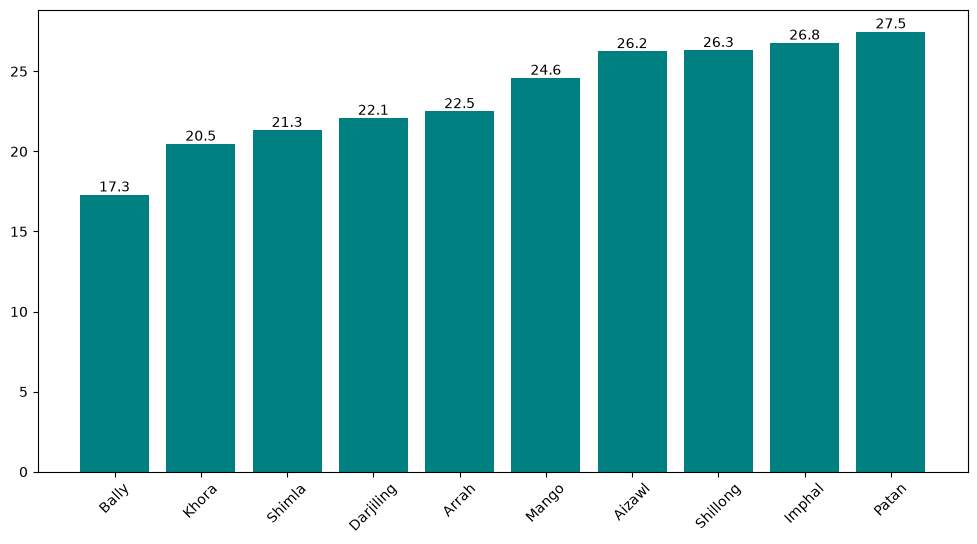

In [60]:
# plotting the graph for the cities with lowest temperature

plt.figure(figsize=(12,6))

bars = plt.bar(df_top_low["name"],df_top_low["temp_c"],color = 'teal')

for bar in bars:
    y = bar.get_height()
    x = bar.get_x() + bar.get_width() / 2

    plt.text(x,y,round(y,1),ha = 'center',va = 'bottom')

plt.xticks(rotation = 45)

plt.show()

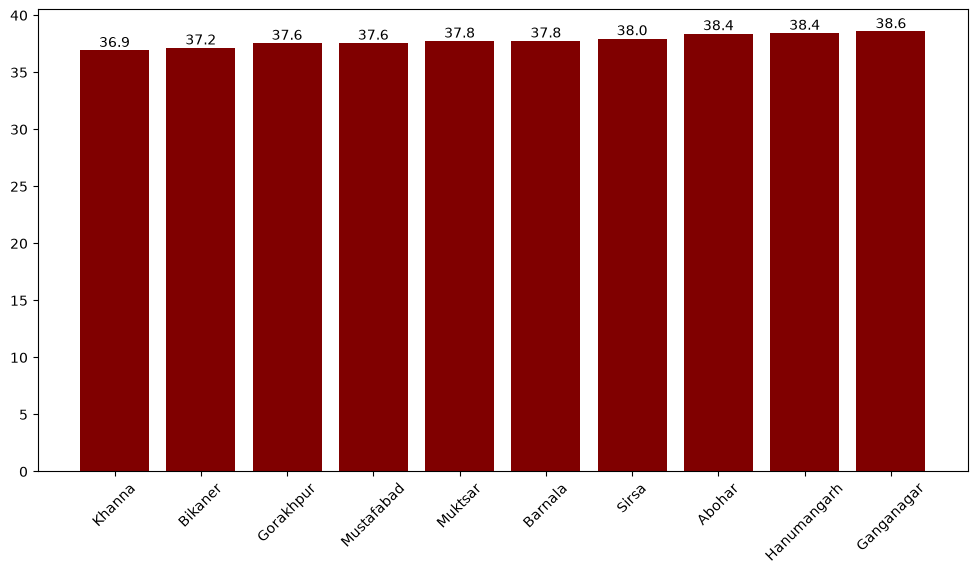

In [63]:
# plotting graph for cities with highest temperatures

plt.figure(figsize = (12,6))

bars = plt.bar(df_top_high["name"],df_top_high["temp_c"], color = 'maroon')

for bar in bars:
    y = bar.get_height()
    x = bar.get_x() + bar.get_width() / 2

    plt.text(x,y,round(y,1), ha = 'center',va = 'bottom')

plt.xticks(rotation = 45)

plt.show()